# Resnet Bayesien - Ajout des transformations

In [1]:
import torch
import torchvision
import numpy as np
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

### Fonctions usuelles

In [2]:
def predictive_entropy(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    return -np.sum(output * np.log(output + 1e-10), axis=-1)

def mutual_information(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
        expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
        return entropy - expected_entropy
    return np.zeros(output.shape[0], dtype=float)

### Fonctions de métriques (ACE, AUCE, plots)

In [3]:
def compute_ace(confidences, correct, n_bins=20):
    bin_boundaries = np.percentile(confidences, np.linspace(0, 100, n_bins + 1))
    bin_idx = np.digitize(confidences, bin_boundaries)

    ace_bin_confidence = []
    ace_bin_accuracy = []
    for b in range(1, n_bins + 1):
        mask = bin_idx == b
        if mask.sum() > 0:
            ace_bin_confidence.append(float(confidences[mask].mean()))
            ace_bin_accuracy.append(float(correct[mask].mean()))

    ace_bin_sizes = [(bin_idx == b).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

    ace = sum(
        s * abs(a - c)
        for s, a, c in zip(ace_bin_sizes, ace_bin_accuracy, ace_bin_confidence)
    ) / len(confidences)

    return ace, ace_bin_confidence, ace_bin_accuracy


def compute_auce(predictive_uncertainty, errors, n_bins=20):
    bin_boundaries = np.percentile(predictive_uncertainty, np.linspace(0, 100, n_bins + 1))
    bin_idx = np.digitize(predictive_uncertainty, bin_boundaries)

    auce_bin_uncertainty = []
    auce_bin_error = []
    for b in range(1, n_bins + 1):
        mask = bin_idx == b
        if mask.sum() > 0:
            auce_bin_uncertainty.append(float(predictive_uncertainty[mask].mean()))
            auce_bin_error.append(float(errors[mask].mean()))

    unc_min = predictive_uncertainty.min()
    unc_max = predictive_uncertainty.max()
    auce_unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in auce_bin_uncertainty]
    auce_bin_sizes = [(bin_idx == b).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

    auce = sum(
        s * abs(e - u)
        for s, e, u in zip(auce_bin_sizes, auce_bin_error, auce_unc_normalized)
    ) / len(errors)

    return auce, auce_bin_uncertainty, auce_bin_error


def plot_uncertain_when_inaccurate(predictive_uncertainty, confidences, correct):
    unc_norm = predictive_uncertainty / predictive_uncertainty.max()

    thresholds_unc = np.linspace(0, 1, 50)
    uncertain_when_inaccurate = []
    inaccurate = (correct == 0)

    for kappa in thresholds_unc:
        above_threshold = unc_norm >= kappa
        if inaccurate.sum() > 0:
            uncertain_when_inaccurate.append(
                (inaccurate & above_threshold).sum() / inaccurate.sum()
            )
        else:
            uncertain_when_inaccurate.append(np.nan)

    thresholds_conf = np.linspace(0, 1, 50)
    confident_when_accurate = []
    for kappa in thresholds_conf:
        mask = confidences >= kappa
        if mask.sum() > 0:
            confident_when_accurate.append(correct[mask].mean())
        else:
            confident_when_accurate.append(np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(thresholds_unc, uncertain_when_inaccurate)
    axes[0].set_xlabel('Uncertainty thresholds')
    axes[0].set_ylabel('p(uncertain | inaccurate)')
    axes[0].set_title('Uncertain when Inaccurate')

    axes[1].plot(thresholds_conf, confident_when_accurate)
    axes[1].set_xlabel('Confidence threshold κ')
    axes[1].set_ylabel('Fraction of accurate predictions')
    axes[1].set_title('Confidence vs Accuracy')

    plt.tight_layout()
    plt.show()


def print_class_accuracy(all_labels, all_preds, class_names):
    class_name_2 = list(class_names.values())
    correct_pred = {classname: 0 for classname in class_name_2}
    total_pred = {classname: 0 for classname in class_name_2}

    for label, pred in zip(all_labels, all_preds):
        name = class_names[str(int(label))]
        if label == pred:
            correct_pred[name] += 1
        total_pred[name] += 1

    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

    return correct_pred, total_pred

### Hyperparametres

In [4]:
learning_rate = 0.001
nb_epoch = 50
batch_size = 128
milestones = [20, 35, 45]
gamma = 0.5
num_monte_carlo = 25

### Load Dataset

In [5]:
from medmnist import PathMNIST
from medmnist import INFO

transform_train = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_eval = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

info = INFO['pathmnist']

trainset = PathMNIST(split="train", download=True, size=28, transform=transform_train)
valset   = PathMNIST(split="val",   download=True, size=28, transform=transform_eval)
testset  = PathMNIST(split="test",  download=True, size=28, transform=transform_eval)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = info['label']
print(f"class names: {class_names}")

class names: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


#### Use GPU

In [6]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

## Partie 1 : EfficientNet classique

### Cree le reseau

In [9]:
net = torchvision.models.efficientnet_b0(progress=True)
net.classifier[1] = nn.Linear(1280, 9)
net.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Training

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [8]:
print(device)

"""train_losses = []
val_losses = []

for epoch in range(nb_epoch):
    net.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer.zero_grad()

        outputs = net(inputs)
        loss_train = criterion(outputs, labels)

        loss_train.backward()
        optimizer.step()

        running_loss_train += loss_train.item()

    train_losses.append(running_loss_train / len(trainloader))

    scheduler.step()

    # Validation
    net.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            outputs = net(inputs)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()

    val_losses.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

torch.save({
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, "models/effnetTranso.pth")

print('Finished Training')"""

net = torchvision.models.efficientnet_b0(progress=True)
net.classifier[1] = nn.Linear(1280, 9)

checkpoint_effnet = torch.load("models/effnetTranso.pth", map_location=device)
net.load_state_dict(checkpoint_effnet['model_state_dict'])
net.to(device)
net.eval()

cuda


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Calcul accuracy

In [10]:
def evaluate_deterministic(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_confs = []

    with torch.no_grad():
        for data in loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            logits = model(inputs)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            y_pred = torch.argmax(probs, dim=1)
            conf = probs.max(dim=1).values

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_confs.append(conf.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    all_confs = np.concatenate(all_confs, axis=0)
    acc = (all_preds == all_labels).mean()

    return all_preds, all_labels, all_probs, all_confs, acc


all_preds_effnet, all_labels_effnet, all_probs_effnet, all_confs_effnet, test_acc_effnet = evaluate_deterministic(net, testloader, device)
_, _, _, _, train_acc_effnet = evaluate_deterministic(net, trainloader, device)
_, _, _, _, val_acc_effnet = evaluate_deterministic(net, valloader, device)

print(f'Train Accuracy : {100 * train_acc_effnet:.3f} %')
print(f'Val Accuracy   : {100 * val_acc_effnet:.3f} %')
print(f'Test Accuracy  : {100 * test_acc_effnet:.3f} %')

Exception in thread Thread-5 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "/home/a992250/bnn/pyenv/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/a992250/bnn/pyenv/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/a992250/bnn/pyenv/lib/python3.12/site-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/li

KeyboardInterrupt: 

### Accuracy par classe

In [ ]:
correct_pred_effnet, total_pred_effnet = print_class_accuracy(all_labels_effnet, all_preds_effnet, class_names)

Accuracy for class: adipose is 91.2 %
Accuracy for class: background is 100.0 %
Accuracy for class: debris is 82.3 %
Accuracy for class: lymphocytes is 98.9 %
Accuracy for class: mucus is 75.0 %
Accuracy for class: smooth muscle is 65.7 %
Accuracy for class: normal colon mucosa is 86.1 %
Accuracy for class: cancer-associated stroma is 44.7 %
Accuracy for class: colorectal adenocarcinoma epithelium is 95.8 %


### Adaptive Certainty Error (ACE)

ACE : 7.70%


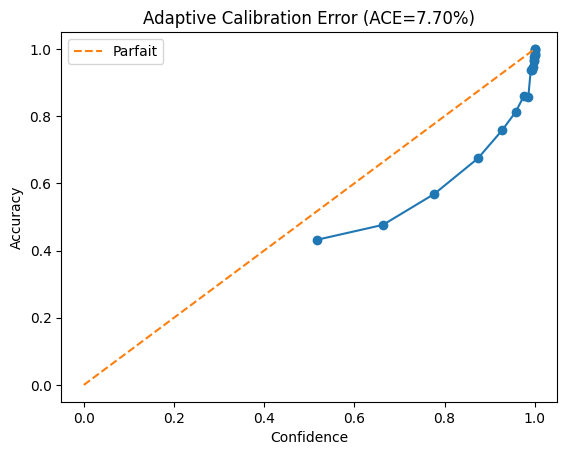

In [ ]:
correct_effnet = (all_preds_effnet == all_labels_effnet).astype(float)

ace_effnet, ace_bin_confidence_effnet, ace_bin_accuracy_effnet = compute_ace(all_confs_effnet, correct_effnet)
print(f'ACE : {100 * ace_effnet:.2f}%')

plt.plot(ace_bin_confidence_effnet, ace_bin_accuracy_effnet, marker='o')
plt.plot([0, 1], [0, 1], '--', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Adaptive Calibration Error (ACE={100 * ace_effnet:.2f}%)')
plt.legend()
plt.show()

### Adaptive Uncertainty Calibration Error (AUCE)

AUCE : 3.97%


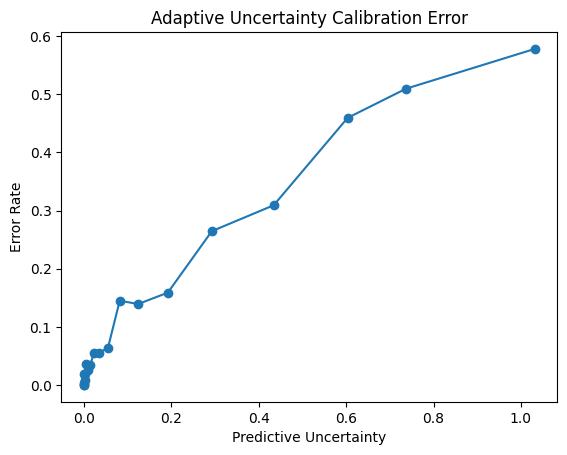

In [ ]:
predictive_uncertainty_effnet = predictive_entropy(all_probs_effnet)

auce_effnet, auce_bin_uncertainty_effnet, auce_bin_error_effnet = compute_auce(predictive_uncertainty_effnet, 1 - correct_effnet)
print(f'AUCE : {100 * auce_effnet:.2f}%')

plt.plot(auce_bin_uncertainty_effnet, auce_bin_error_effnet, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Adaptive Uncertainty Calibration Error')
plt.show()

### Plot Uncertain when Inaccurate + Confidence vs Accuracy

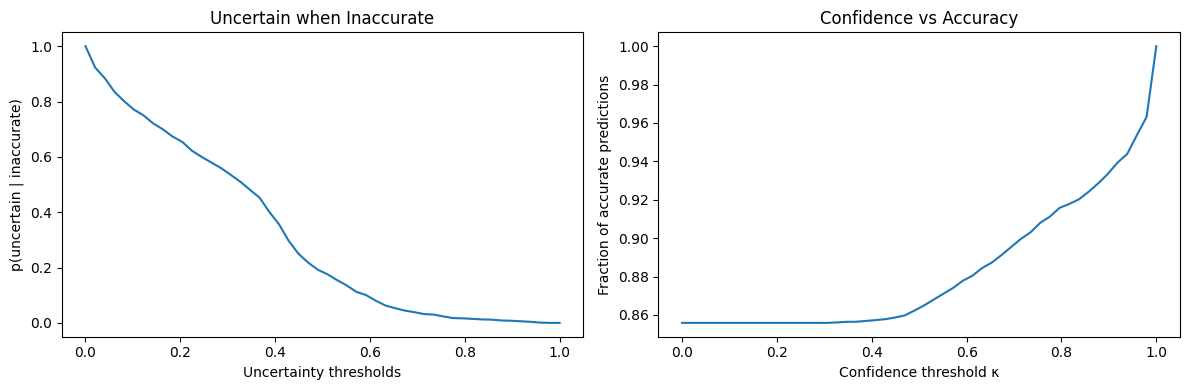

In [ ]:
plot_uncertain_when_inaccurate(predictive_uncertainty_effnet, all_confs_effnet, correct_effnet)

## Partie 2 : Reseau bayesien no moped à partir de l'effnet

### Cree le reseau bayesien

In [7]:
const_bnn_prior_parameters_no_moped = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Reparameterization",
    "moped_enable": False,
    "moped_delta": 0.5,
}

net_bayesian = torchvision.models.efficientnet_b0(progress=True)
net_bayesian.classifier[1] = nn.Linear(1280, 9)

red_effnet = torch.load("models/effnetTranso.pth", map_location=device)
net_bayesian.load_state_dict(red_effnet['model_state_dict'])

dnn_to_bnn(net_bayesian, const_bnn_prior_parameters_no_moped)
net_bayesian.to(device)

print(net_bayesian)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2dReparameterization()
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2dReparameterization()
            (fc2): Conv2dReparameterization()
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivation(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

### Training

In [11]:
optimizer_bay = torch.optim.Adam(net_bayesian.parameters(), lr=learning_rate)
scheduler_bay = optim.lr_scheduler.MultiStepLR(optimizer_bay, milestones=milestones, gamma=gamma)

In [12]:
print(device)
"""

train_losses_bay = []
val_losses_bay = []

for epoch in range(nb_epoch):
    net_bayesian.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer_bay.zero_grad()

        output = net_bayesian(inputs)
        kl = get_kl_loss(net_bayesian)
        ce_loss = criterion(output, labels)
        loss_train = ce_loss + kl / len(trainset)

        loss_train.backward()
        optimizer_bay.step()

        running_loss_train += loss_train.item()

    train_losses_bay.append(running_loss_train / len(trainloader))

    scheduler_bay.step()

    # Validation
    net_bayesian.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            outputs = net_bayesian(inputs)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()

    val_losses_bay.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

torch.save({
    'model_state_dict': net_bayesian.state_dict(),
    'optimizer_state_dict': optimizer_bay.state_dict(),
    'train_losses': train_losses_bay,
    'val_losses': val_losses_bay,
}, "models/BayNoMopedTransfo.pth")

print('Finished Training')
"""

# Reseau bayesien no moped
const_bnn_prior_parameters_no_moped = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Reparameterization",
    "moped_enable": False,
    "moped_delta": 0.5,
}

net_bayesian = torchvision.models.efficientnet_b0(progress=True)
net_bayesian.classifier[1] = nn.Linear(1280, 9)
dnn_to_bnn(net_bayesian, const_bnn_prior_parameters_no_moped)

checkpoint_bay = torch.load("models/entropy_pruning/model_iter_3.pth", map_location=device, weights_only=False)
net_bayesian.load_state_dict(checkpoint_bay['model_state_dict'])
net_bayesian.to(device)
net_bayesian.eval()

cuda


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2dReparameterization()
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2dReparameterization()
            (fc2): Conv2dReparameterization()
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivation(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

### Calcul accuracy

In [13]:
def evaluate_bayesian(model, loader, num_monte_carlo, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_outputs = []
    all_confs = []

    with torch.no_grad():
        for data in loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            output_mc = []
            for _ in range(num_monte_carlo):
                logits = model(inputs)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)

            output = torch.stack(output_mc)
            pred_mean = output.mean(dim=0)
            y_pred = torch.argmax(pred_mean, dim=1)
            conf = pred_mean.max(dim=1).values

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(output.cpu().numpy())
            all_confs.append(conf.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=1)
    all_confs = np.concatenate(all_confs, axis=0)
    acc = (all_preds == all_labels).mean()

    return all_preds, all_labels, all_outputs, all_confs, acc


all_preds_bay, all_labels_bay, all_outputs_bay, all_confs_bay, test_acc_bay = evaluate_bayesian(net_bayesian, testloader, num_monte_carlo, device)
_, _, _, _, train_acc_bay = evaluate_bayesian(net_bayesian, trainloader, num_monte_carlo, device)
_, _, _, _, val_acc_bay = evaluate_bayesian(net_bayesian, valloader, num_monte_carlo, device)

print(f'Train Accuracy : {100 * train_acc_bay:.3f} %')
print(f'Val Accuracy   : {100 * val_acc_bay:.3f} %')
print(f'Test Accuracy  : {100 * test_acc_bay:.3f} %')

Train Accuracy : 91.195 %
Val Accuracy   : 92.253 %
Test Accuracy  : 85.613 %


### Accuracy par classe

In [14]:
correct_pred_bay, total_pred_bay = print_class_accuracy(all_labels_bay, all_preds_bay, class_names)

Accuracy for class: adipose is 98.7 %
Accuracy for class: background is 100.0 %
Accuracy for class: debris is 86.1 %
Accuracy for class: lymphocytes is 89.7 %
Accuracy for class: mucus is 84.2 %
Accuracy for class: smooth muscle is 59.0 %
Accuracy for class: normal colon mucosa is 85.2 %
Accuracy for class: cancer-associated stroma is 37.1 %
Accuracy for class: colorectal adenocarcinoma epithelium is 90.2 %


### Adaptive Certainty Error (ACE)

ACE : 3.04%


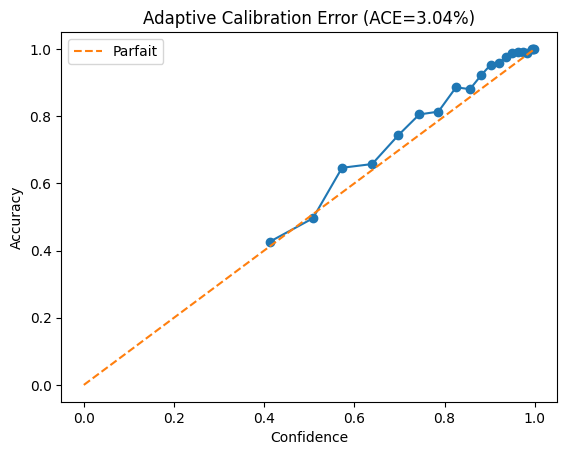

In [15]:
correct_bay = (all_preds_bay == all_labels_bay).astype(float)

ace_bay, ace_bin_confidence_bay, ace_bin_accuracy_bay = compute_ace(all_confs_bay, correct_bay)
print(f'ACE : {100 * ace_bay:.2f}%')

plt.plot(ace_bin_confidence_bay, ace_bin_accuracy_bay, marker='o')
plt.plot([0, 1], [0, 1], '--', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Adaptive Calibration Error (ACE={100 * ace_bay:.2f}%)')
plt.legend()
plt.show()

### Adaptive Uncertainty Calibration Error (AUCE)

AUCE : 13.18%


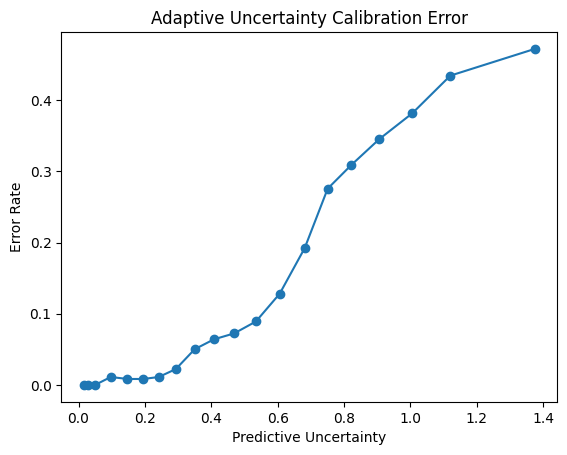

In [16]:
predictive_uncertainty_bay = predictive_entropy(all_outputs_bay)

auce_bay, auce_bin_uncertainty_bay, auce_bin_error_bay = compute_auce(predictive_uncertainty_bay, 1 - correct_bay)
print(f'AUCE : {100 * auce_bay:.2f}%')

plt.plot(auce_bin_uncertainty_bay, auce_bin_error_bay, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Adaptive Uncertainty Calibration Error')
plt.show()

### Plot Uncertain when Inaccurate + Confidence vs Accuracy

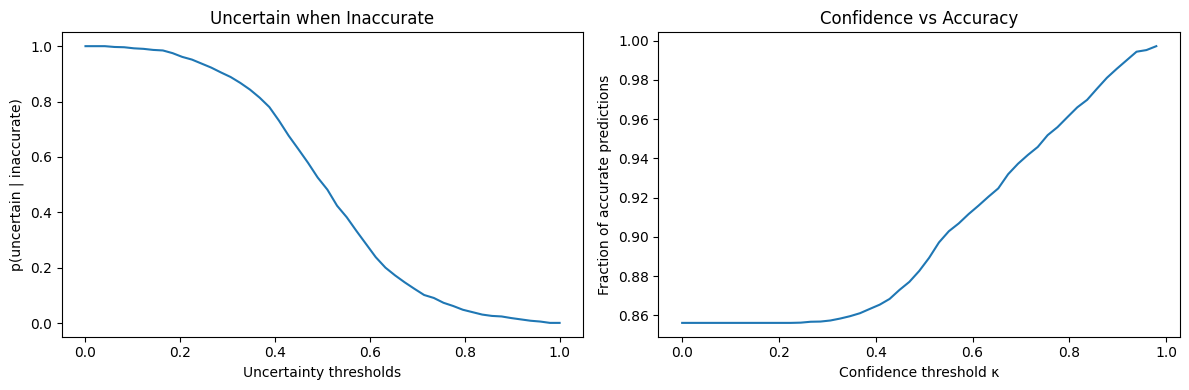

In [17]:
plot_uncertain_when_inaccurate(predictive_uncertainty_bay, all_confs_bay, correct_bay)

### Mutual Information Chart

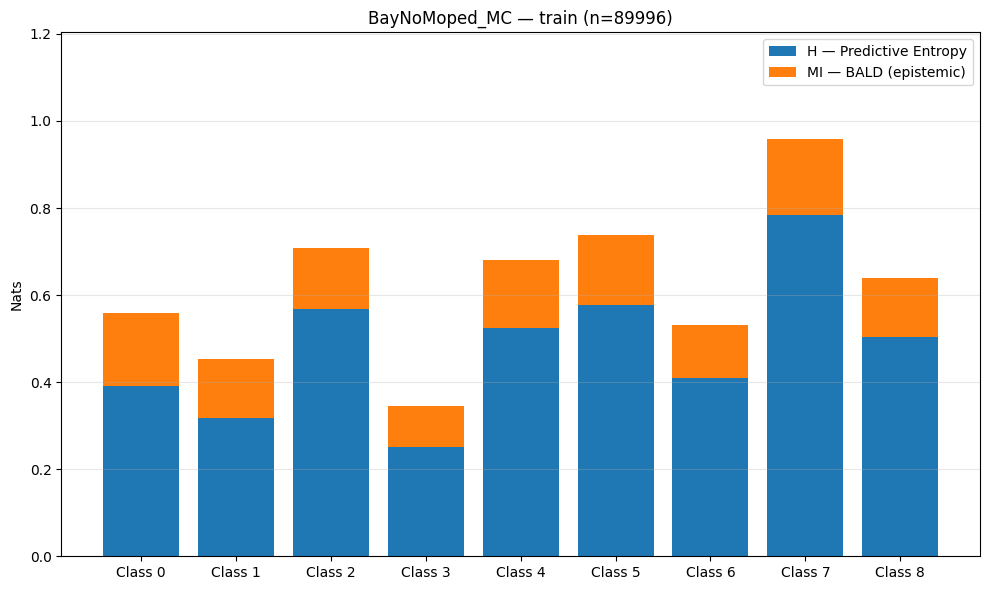

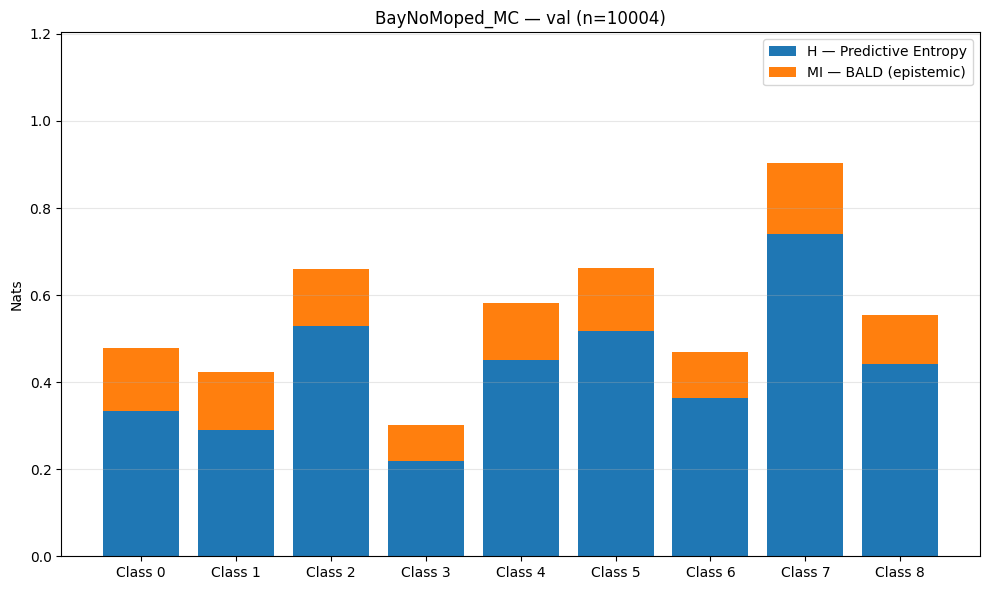

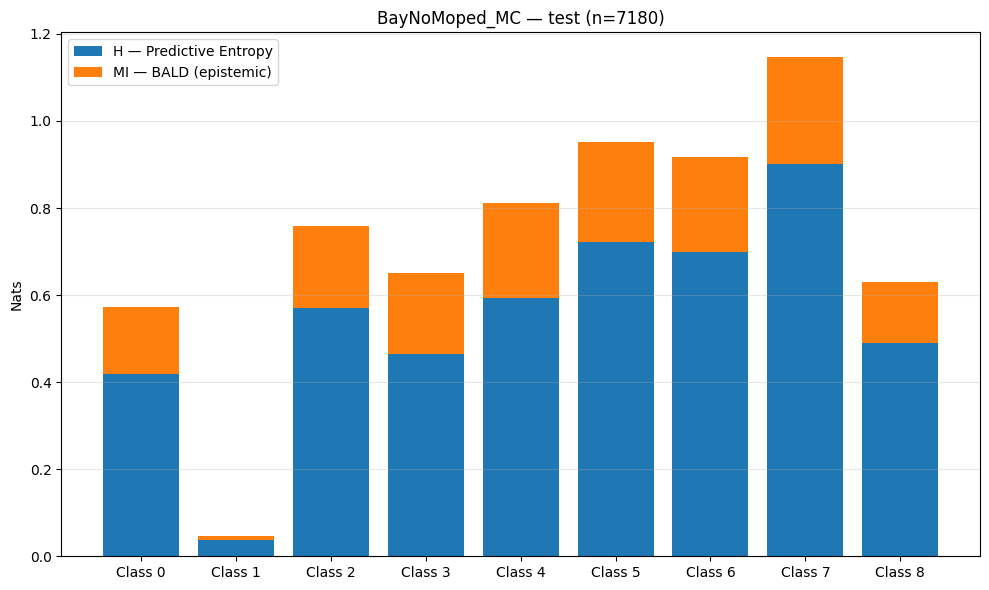

In [18]:
def compute_entropy_mi_per_class(all_outputs, all_labels, n_classes):
    entropy = predictive_entropy(all_outputs)
    mi = mutual_information(all_outputs)

    mean_entropy = np.zeros(n_classes)
    mean_mi = np.zeros(n_classes)

    for c in range(n_classes):
        mask = all_labels == c
        if mask.sum() > 0:
            mean_entropy[c] = entropy[mask].mean()
            mean_mi[c] = mi[mask].mean()

    return mean_entropy, mean_mi


def plot_entropy_mi_per_class(mean_entropy, mean_mi, split_name, n, ylim):
    n_classes = len(mean_entropy)
    x = np.arange(n_classes)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, mean_entropy, label='H — Predictive Entropy', color='#1f77b4')
    ax.bar(x, mean_mi, bottom=mean_entropy, label='MI — BALD (epistemic)', color='#ff7f0e')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Class {i}' for i in range(n_classes)])
    ax.set_ylabel('Nats')
    ax.set_title(f'BayNoMoped_MC — {split_name} (n={n})')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()


# recalcule les outputs MC pour chaque split (garde all_outputs cette fois, contrairement au calcul d'accuracy plus haut)
_, all_labels_bay_train, all_outputs_bay_train, _, _ = evaluate_bayesian(net_bayesian, trainloader, num_monte_carlo, device)
_, all_labels_bay_val, all_outputs_bay_val, _, _ = evaluate_bayesian(net_bayesian, valloader, num_monte_carlo, device)
# pour le test, all_outputs_bay et all_labels_bay sont deja disponibles (calcules plus haut)

n_classes = len(class_names)

mean_entropy_train, mean_mi_train = compute_entropy_mi_per_class(all_outputs_bay_train, all_labels_bay_train, n_classes)
mean_entropy_val, mean_mi_val = compute_entropy_mi_per_class(all_outputs_bay_val, all_labels_bay_val, n_classes)
mean_entropy_test, mean_mi_test = compute_entropy_mi_per_class(all_outputs_bay, all_labels_bay, n_classes)

# echelle fixe et identique pour les 3 graphiques
global_max = max(
    (mean_entropy_train + mean_mi_train).max(),
    (mean_entropy_val + mean_mi_val).max(),
    (mean_entropy_test + mean_mi_test).max(),
)
ylim = (0, global_max * 1.05)

plot_entropy_mi_per_class(mean_entropy_train, mean_mi_train, "train", len(all_labels_bay_train), ylim)
plot_entropy_mi_per_class(mean_entropy_val, mean_mi_val, "val", len(all_labels_bay_val), ylim)
plot_entropy_mi_per_class(mean_entropy_test, mean_mi_test, "test", len(all_labels_bay), ylim)

### Loop

In [22]:
import os, json
from torch.utils.data import Subset


def train_bnn_from_scratch(subset, num_epochs=nb_epoch):
    loader = torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    model = torchvision.models.efficientnet_b0(progress=True)
    model.classifier[1] = nn.Linear(1280, 9)
    dnn_to_bnn(model, const_bnn_prior_parameters_no_moped)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.squeeze(1)
            optimizer.zero_grad()

            output = model(inputs)
            kl = get_kl_loss(model)
            loss = criterion(output, labels) + kl / len(subset)

            loss.backward()
            optimizer.step()
        scheduler.step()

    return model


def compute_entropy_per_sample(model, dataset, num_monte_carlo, device):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    model.eval()
    all_entropy = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            output_mc = []
            for _ in range(num_monte_carlo):
                logits = model(inputs)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)
            output = torch.stack(output_mc)  # (mc, batch, classes)
            entropy = predictive_entropy(output.cpu().numpy())
            all_entropy.append(entropy)

    return np.concatenate(all_entropy, axis=0)

def evaluate_bayesian(model, loader, num_monte_carlo, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_outputs = []
    all_confs = []

    with torch.no_grad():
        for data in loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            output_mc = []
            for _ in range(num_monte_carlo):
                logits = model(inputs)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)

            output = torch.stack(output_mc)
            pred_mean = output.mean(dim=0)
            y_pred = torch.argmax(pred_mean, dim=1)
            conf = pred_mean.max(dim=1).values

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(output.cpu().numpy())
            all_confs.append(conf.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=1)
    all_confs = np.concatenate(all_confs, axis=0)
    acc = (all_preds == all_labels).mean()

    return all_preds, all_labels, all_outputs, all_confs, acc


current_indices = np.arange(len(trainset))
mean_entropy_history = []
val_accuracy_history = []
tolerance = 1e-3
max_iterations = 10

iteration = 0
prev_mean_entropy = None
best_model = None
best_val_accuracy = None

checkpoint_dir = "models/entropy_pruning"
os.makedirs(checkpoint_dir, exist_ok=True)
history_path = os.path.join(checkpoint_dir, "history.json")

# --- Reprise si un historique existe deja ---
if os.path.exists(history_path):
    with open(history_path, "r") as f:
        state = json.load(f)
    mean_entropy_history = state["mean_entropy_history"]
    val_accuracy_history = state["val_accuracy_history"]
    current_indices = np.array(state["current_indices"])
    iteration = state["iteration"]
    prev_mean_entropy = mean_entropy_history[-1] if mean_entropy_history else None
    print(f"Reprise a l'iteration {iteration}, n_train = {len(current_indices)}")
else:
    mean_entropy_history = []
    val_accuracy_history = []
    current_indices = np.arange(len(trainset))
    iteration = 0
    prev_mean_entropy = None

tolerance = 1e-3
max_iterations = 10

while iteration < max_iterations:
    subset = Subset(trainset, current_indices)
    print(f"--- Iteration {iteration} | n_train = {len(subset)} ---")

    model = train_bnn_from_scratch(subset)

    entropy_scores = compute_entropy_per_sample(model, subset, num_monte_carlo, device)
    mean_entropy = entropy_scores.mean()

    _, _, _, _, val_acc = evaluate_bayesian(model, valloader, num_monte_carlo, device)

    print(f"Mean entropy (train): {mean_entropy:.4f}")
    print(f"Val accuracy: {100 * val_acc:.3f} %")

    # --- Sauvegarde du modele de cette iteration, quoi qu'il arrive ---
    torch.save({
        'model_state_dict': model.state_dict(),
        'iteration': iteration,
        'n_train': len(subset),
        'mean_entropy': mean_entropy,
        'val_accuracy': val_acc,
    }, os.path.join(checkpoint_dir, f"model_iter_{iteration}.pth"))

    mean_entropy_history.append(float(mean_entropy))
    val_accuracy_history.append(float(val_acc))

    stop = False
    if prev_mean_entropy is not None:
        improvement = prev_mean_entropy - mean_entropy
        print(f"Amelioration entropie vs iteration precedente: {improvement:.4f}")
        if improvement <= tolerance:
            print("Entropie stagnante, arret.")
            stop = True

    prev_mean_entropy = mean_entropy

    n_remove = int(0.05 * len(subset))
    keep_mask = np.argsort(entropy_scores)[:-n_remove]
    next_indices = current_indices[keep_mask]

    iteration += 1

    # --- Sauvegarde de l'etat global (permet la reprise) ---
    with open(history_path, "w") as f:
        json.dump({
            "mean_entropy_history": mean_entropy_history,
            "val_accuracy_history": val_accuracy_history,
            "current_indices": next_indices.tolist(),
            "iteration": iteration,
        }, f, indent=2)

    if stop:
        break

    current_indices = next_indices

print("Historique entropie moyenne (train) :", mean_entropy_history)
print("Historique accuracy (val) :", [100 * a for a in val_accuracy_history])

Reprise a l'iteration 1, n_train = 85497
--- Iteration 1 | n_train = 85497 ---
Mean entropy (train): 0.4977
Val accuracy: 92.723 %
Amelioration entropie vs iteration precedente: 0.1140
--- Iteration 2 | n_train = 81223 ---
Mean entropy (train): 0.4250
Val accuracy: 92.633 %
Amelioration entropie vs iteration precedente: 0.0727
--- Iteration 3 | n_train = 77162 ---
Mean entropy (train): 0.3919
Val accuracy: 92.503 %
Amelioration entropie vs iteration precedente: 0.0331
--- Iteration 4 | n_train = 73304 ---
Mean entropy (train): 0.3785
Val accuracy: 91.913 %
Amelioration entropie vs iteration precedente: 0.0133
--- Iteration 5 | n_train = 69639 ---
Mean entropy (train): 0.4775
Val accuracy: 87.705 %
Amelioration entropie vs iteration precedente: -0.0989
Entropie stagnante, arret.
Historique entropie moyenne (train) : [0.6117503643035889, 0.497713565826416, 0.4250359535217285, 0.39189350605010986, 0.37854573130607605, 0.47748759388923645]
Historique accuracy (val) : [93.19272291083567, 92

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

class_names_list = list(class_names.values())

# ============================================================
# 1. Matrice de confusion complete (pour contexte), avec zoom classes 7 et 8
# ============================================================
cm = confusion_matrix(all_labels_bay, all_preds_bay, labels=list(range(len(class_names_list))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Matrice complete ---
ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names_list)))
ax.set_yticks(range(len(class_names_list)))
ax.set_xticklabels(class_names_list, rotation=45, ha="right")
ax.set_yticklabels(class_names_list)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Matrice de confusion complete (test)")
for i in range(len(class_names_list)):
    for j in range(len(class_names_list)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Zoom classes 7 et 8 : lignes = vraies classes 7/8, toutes colonnes ---
target_classes = [7, 8]
ax = axes[1]
cm_zoom = cm[target_classes, :]
im2 = ax.imshow(cm_zoom, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(class_names_list)))
ax.set_yticks(range(len(target_classes)))
ax.set_xticklabels(class_names_list, rotation=45, ha="right")
ax.set_yticklabels([class_names_list[c] for c in target_classes])
ax.set_xlabel("Predicted")
ax.set_ylabel("True (classes 7 et 8)")
ax.set_title("Zoom : ou partent les erreurs des classes 7 et 8 ?")
for i in range(len(target_classes)):
    for j in range(len(class_names_list)):
        ax.text(j, i, cm_zoom[i, j], ha="center", va="center",
                color="white" if cm_zoom[i, j] > cm_zoom.max() / 2 else "black", fontsize=8)
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("confusion_matrix_classes_7_8.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Accuracy et confusions principales pour ces 2 classes ---
for c in target_classes:
    mask = all_labels_bay == c
    n_total = mask.sum()
    n_correct = (all_preds_bay[mask] == c).sum()
    acc = 100 * n_correct / n_total

    row = cm[c, :].copy()
    row[c] = 0  # on exclut la diagonale pour trouver la confusion principale
    top_confused_idx = row.argmax()

    print(f"Classe {c} ({class_names_list[c]}) : accuracy = {acc:.1f}% "
          f"({n_correct}/{n_total}), confondue le plus souvent avec "
          f"'{class_names_list[top_confused_idx]}' ({row[top_confused_idx]} fois)")

# ============================================================
# 2. Lien entre Mutual Information (epistemique) et accuracy, par echantillon
# ============================================================
mi_per_sample = mutual_information(all_outputs_bay)  # (n_samples,)

n_bins = 10
bin_edges = np.percentile(mi_per_sample, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(mi_per_sample, bin_edges)

bin_mi_mean = []
bin_accuracy = []
bin_sizes = []

for b in range(1, n_bins + 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_mi_mean.append(mi_per_sample[mask].mean())
        bin_accuracy.append(100 * (all_preds_bay[mask] == all_labels_bay[mask]).mean())
        bin_sizes.append(mask.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Courbe MI vs accuracy (global) ---
ax = axes[0]
ax.plot(bin_mi_mean, bin_accuracy, marker="o", color="#e63946")
ax.set_xlabel("Mutual Information moyenne (bin)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("MI vs Accuracy (global, tous echantillons)")
ax.grid(alpha=0.3)

# --- Meme chose mais seulement pour classes 7 et 8 ---
ax = axes[1]
colors = {"7": "#f4a261", "8": "#2a9d8f"}
for c in target_classes:
    mask_class = all_labels_bay == c
    mi_class = mi_per_sample[mask_class]
    correct_class = (all_preds_bay[mask_class] == all_labels_bay[mask_class]).astype(float)

    bin_edges_c = np.percentile(mi_class, np.linspace(0, 100, n_bins + 1))
    bin_idx_c = np.digitize(mi_class, bin_edges_c)

    bin_mi_c, bin_acc_c = [], []
    for b in range(1, n_bins + 1):
        mask_b = bin_idx_c == b
        if mask_b.sum() > 0:
            bin_mi_c.append(mi_class[mask_b].mean())
            bin_acc_c.append(100 * correct_class[mask_b].mean())

    ax.plot(bin_mi_c, bin_acc_c, marker="o", color=colors[str(c)],
            label=class_names_list[c])

ax.set_xlabel("Mutual Information moyenne (bin)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("MI vs Accuracy — classes 7 et 8 uniquement")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mi_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Correlation numerique MI / erreur ---
from scipy.stats import pointbiserialr

incorrect_bay = (all_preds_bay != all_labels_bay).astype(int)
corr_global, pval_global = pointbiserialr(incorrect_bay, mi_per_sample)
print(f"\nCorrelation (point-biserial) MI / erreur, global : r = {corr_global:.3f} (p = {pval_global:.2e})")

for c in target_classes:
    mask_class = all_labels_bay == c
    corr_c, pval_c = pointbiserialr(incorrect_bay[mask_class], mi_per_sample[mask_class])
    print(f"Classe {c} ({class_names_list[c]}) : r = {corr_c:.3f} (p = {pval_c:.2e})")

### Exporte les résultats

In [19]:
import json
import csv
import os

def json_safe(obj):
    if isinstance(obj, dict):
        return {json_safe(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return json_safe(obj.tolist())
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, float):
        if np.isnan(obj) or np.isinf(obj):
            return None
        return obj
    return obj


def compute_uncertain_curves(predictive_uncertainty, confidences, correct):
    unc_norm = predictive_uncertainty / predictive_uncertainty.max()

    thresholds_unc = np.linspace(0, 1, 50)
    uncertain_when_inaccurate = []
    inaccurate = (correct == 0)

    for kappa in thresholds_unc:
        above_threshold = unc_norm >= kappa
        if inaccurate.sum() > 0:
            uncertain_when_inaccurate.append(
                float((inaccurate & above_threshold).sum() / inaccurate.sum())
            )
        else:
            uncertain_when_inaccurate.append(np.nan)

    thresholds_conf = np.linspace(0, 1, 50)
    confident_when_accurate = []
    for kappa in thresholds_conf:
        mask = confidences >= kappa
        if mask.sum() > 0:
            confident_when_accurate.append(float(correct[mask].mean()))
        else:
            confident_when_accurate.append(np.nan)

    return thresholds_unc, uncertain_when_inaccurate, thresholds_conf, confident_when_accurate


thresholds_unc_bay, uncertain_when_inaccurate_bay, thresholds_conf_bay, confident_when_accurate_bay = \
    compute_uncertain_curves(predictive_uncertainty_bay, all_confs_bay, correct_bay)

mean_entropy_train, mean_mi_train = compute_entropy_mi_per_class(all_outputs_bay_train, all_labels_bay_train, len(class_names))
mean_entropy_val, mean_mi_val = compute_entropy_mi_per_class(all_outputs_bay_val, all_labels_bay_val, len(class_names))
mean_entropy_test, mean_mi_test = compute_entropy_mi_per_class(all_outputs_bay, all_labels_bay, len(class_names))

# --- Nouvelle entree a ajouter/mettre a jour ---
new_entry = {
    "bay_no_moped_3_iterations": {
        "train_accuracy": float(100 * train_acc_bay),
        "val_accuracy": float(100 * val_acc_bay),
        "test_accuracy": float(100 * test_acc_bay),
        "ace": float(100 * ace_bay),
        "auce": float(100 * auce_bay),
        "class_accuracy": {
            name: float(100 * correct_pred_bay[name] / total_pred_bay[name])
            for name in correct_pred_bay
        },
        "ace_bin_confidence": list(ace_bin_confidence_bay),
        "ace_bin_accuracy": list(ace_bin_accuracy_bay),
        "auce_bin_uncertainty": list(auce_bin_uncertainty_bay),
        "auce_bin_error": list(auce_bin_error_bay),
        "thresholds_unc": thresholds_unc_bay.tolist(),
        "uncertain_when_inaccurate": uncertain_when_inaccurate_bay,
        "thresholds_conf": thresholds_conf_bay.tolist(),
        "confident_when_accurate": confident_when_accurate_bay,
        "entropy_mi_per_class": {
            "train": {
                "n": len(all_labels_bay_train),
                "mean_entropy": mean_entropy_train.tolist(),
                "mean_mi": mean_mi_train.tolist(),
            },
            "val": {
                "n": len(all_labels_bay_val),
                "mean_entropy": mean_entropy_val.tolist(),
                "mean_mi": mean_mi_val.tolist(),
            },
            "test": {
                "n": len(all_labels_bay),
                "mean_entropy": mean_entropy_test.tolist(),
                "mean_mi": mean_mi_test.tolist(),
            },
        },
    },
}

# --- Charger l'existant s'il y en a un, puis merger ---
if os.path.exists("results.json"):
    with open("results.json", "r") as f:
        results = json.load(f)
else:
    results = {}

results.update(new_entry)  # ajoute/remplace uniquement la ou les clefs de new_entry

with open("results.json", "w") as f:
    json.dump(json_safe(results), f, indent=2)

# --- CSV : reecrit entierement a partir de "results" merge, pas juste new_entry ---
with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    header = ["model", "train_accuracy", "val_accuracy", "test_accuracy", "ace", "auce"] + list(class_names.values())
    writer.writerow(header)
    for model_name, metrics in results.items():
        row = [
            model_name,
            metrics["train_accuracy"],
            metrics["val_accuracy"],
            metrics["test_accuracy"],
            metrics["ace"],
            metrics["auce"],
        ] + [metrics["class_accuracy"][name] for name in class_names.values()]
        writer.writerow(row)

print(f"Resultats fusionnes et exportes ({len(results)} modeles au total)")

Resultats fusionnes et exportes (4 modeles au total)
